# Linear Regression

In [ ]:
import time
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv("/content/cleaned_sentiment140.csv")
features = pd.read_csv("/content/handcrafted_features.csv")

tfidf = joblib.load("/content/tfidf_vectorizer.pkl")
scaler = joblib.load("/content/feature_scaler.pkl")

train_idx = joblib.load("/content/train_indices.pkl")
test_idx = joblib.load("/content/test_indices.pkl")

In [ ]:
print(data.shape)
print(features.shape)

print(len(train_idx))
print(len(test_idx))

(1592688, 7)
(1592688, 19)
1274150
318538


In [ ]:
x = data["clean_text"]
y = data["target"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
joblib.dump(x_train.index, "train_indices.pkl")
joblib.dump(x_test.index, "test_indices.pkl")

['test_indices.pkl']

In [ ]:
joblib.dump(x_train, "x_train.pkl")
joblib.dump(x_test, "x_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

In [ ]:
x_train_tf = tfidf.transform(x_train)
x_test_tf  = tfidf.transform(x_test)

In [ ]:
print(x_train_tf.shape)
print(x_test_tf.shape)

(1274150, 50000)
(318538, 50000)


In [ ]:
features_train = features.loc[x_train.index]
features_test  = features.loc[x_test.index]

In [ ]:
print(features_train.shape)
print(features_test.shape)

(1274150, 19)
(318538, 19)


In [ ]:
fea_tr_scaled = scaler.transform(features_train)
fea_te_scaled = scaler.transform(features_test)

In [ ]:
fea_tr_sparse = csr_matrix(fea_tr_scaled)
fea_te_sparse = csr_matrix(fea_te_scaled)

In [ ]:
x_train_final = hstack([
    x_train_tf, fea_tr_sparse
])
x_test_final = hstack([
    x_test_tf, fea_te_sparse
])

In [ ]:
print(x_train_final.shape)
print(x_test_final.shape)

(1274150, 50019)
(318538, 50019)


## BaseLine Model

In [ ]:
base_model = LogisticRegression(
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

In [ ]:
start = time.time()
base_model.fit(x_train_tf, y_train)
end = time.time()
print(f"Training Time: {end-start:.2f} Seconds")

Training Time: 15.82 Seconds


In [ ]:
# Prediction

start = time.time()
y_pred = base_model.predict(x_test_tf)
end = time.time()
print(f"Testing Time: {end-start:.2f} Seconds")

Testing Time: 0.03 Seconds


In [ ]:
# Probabilities
y_prob = base_model.predict_proba(x_test_tf)[:,1]
print(y_prob)

[0.56792607 0.14369741 0.31388449 ... 0.00470963 0.28237186 0.61505434]


In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7876
Precision: 0.7765
Recall   : 0.8076
F1 Score : 0.7917
ROC AUC  : 0.8682


In [ ]:
# Classification Report
print(f"Classification_Report: \n \n {classification_report(y_test, y_pred)}")

Classification_Report: 
 
               precision    recall  f1-score   support

           0       0.80      0.77      0.78    159267
           1       0.78      0.81      0.79    159271

    accuracy                           0.79    318538
   macro avg       0.79      0.79      0.79    318538
weighted avg       0.79      0.79      0.79    318538



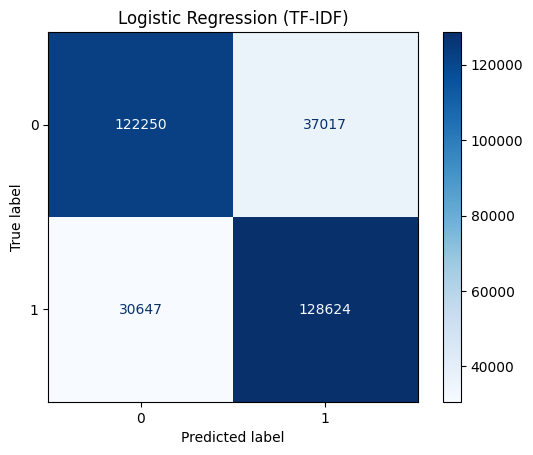

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap = "Blues"
)

plt.title("Logistic Regression (TF-IDF)")
plt.show()

In [ ]:
joblib.dump(base_model, "lr_base_model.pkl")

['lr_base_model.pkl']

## Advanced Model

In [ ]:
print(features_train.shape)
print(features_test.shape)

(1274150, 19)
(318538, 19)


In [ ]:
print(x_train_final.shape)
print(x_test_final.shape)

(1274150, 50019)
(318538, 50019)


In [ ]:
# lr_advanced = LogisticRegression(
#     penalty="l2",          # Regularization
#     C=2.0,                 # Regularization strength
#     solver="liblinear",    # Good for binary classification
#     max_iter=2000,         # More iterations if needed
#     class_weight="balanced", # Useful if classes are imbalanced
#     tol=1e-4,              # Convergence tolerance
#     random_state=42,
#     n_jobs=-1              # Use all CPU cores (ignored by liblinear)
# )

In [ ]:
# Why saga?
# Better suited for very large sparse datasets.

adv_lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
start = time.time()
adv_lr.fit(x_train_tf, y_train)
end = time.time()
print(f"Training Time: {end-start:.2f} Seconds")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


convergence after 24 epochs took 45 seconds
Training Time: 44.38 Seconds


In [ ]:
# Prediction

start = time.time()
y_pred_adv = adv_lr.predict(x_test_tf)
end = time.time()
print(f"Testing Time: {end-start:.2f} Seconds")

Testing Time: 0.02 Seconds


In [ ]:
y_prob_adv = adv_lr.predict_proba(x_test_tf)[:,1]
print(y_prob_adv)

[0.67903617 0.05825675 0.43394412 ... 0.00291358 0.12041503 0.65897089]


In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_adv):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adv):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_adv):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_adv):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_adv):.4f}")

Accuracy : 0.7954
Precision: 0.7852
Recall   : 0.8133
F1 Score : 0.7990
ROC AUC  : 0.8767


In [ ]:
# Classification Report
print(f"Classification_Report: \n \n {classification_report(y_test, y_pred_adv)}")

Classification_Report: 
 
               precision    recall  f1-score   support

           0       0.81      0.78      0.79    159267
           1       0.79      0.81      0.80    159271

    accuracy                           0.80    318538
   macro avg       0.80      0.80      0.80    318538
weighted avg       0.80      0.80      0.80    318538



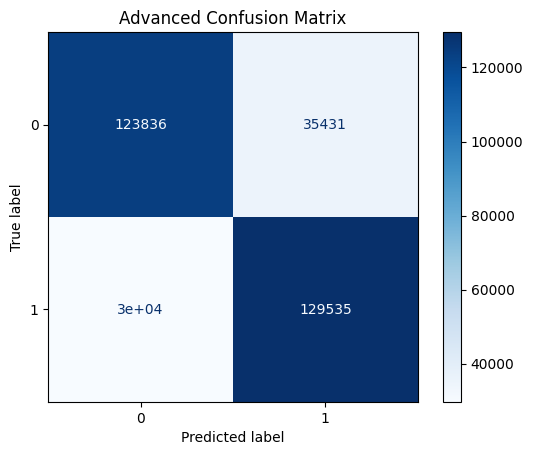

In [ ]:
# Confusion Matric
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_adv,
    cmap='Blues'
)
plt.title("Advanced Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(adv_lr, "lr_adv_model")

['lr_adv_model']